In [1]:
!pip install dataretrieval
!pip install duckdb

# Housekeeping 

Ensure we have directories to put things in!


In [2]:
import os
# Create local directory structure if they don't exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/bronze", exist_ok=True)
os.makedirs("data/quarantine", exist_ok=True)
os.makedirs("data/silver", exist_ok=True)

# Lets Race

I want to do a brief test to see the comparative speed of the workflow: duckdb on a parquet file to load a df, vs pandas loading from parquet and then doing the ops in memory.

In [3]:
import pandas as pd
import duckdb
import time

def test_duckdb(file_path):
    start_time = time.time()
    
    # DuckDB queries the file directly on disk
    query = f"""
    SELECT 
        COUNT_IF(MonitoringLocationName ILIKE '%unknown%') AS unknown_count,
        COUNT_IF(MonitoringLocationName IS NULL) AS null_count,
        COUNT(*) AS total_count
    FROM read_parquet('{file_path}')
    """
    # Execute and fetch as a dataframe (just to make the output format match Pandas)
    res = duckdb.query(query).df() 
    
    end_time = time.time()
    return end_time - start_time

def test_pandas(file_path):
    start_time = time.time()
    
    # Pandas must load the ENTIRE file (or specific columns) into RAM first
    df = pd.read_parquet(file_path)
    
    # Perform the pandas equivalents
    unknown_count = df['MonitoringLocationName'].str.contains('unknown', case=False, na=False).sum()
    null_count = df['MonitoringLocationName'].isna().sum()
    total_count = len(df)
    
    end_time = time.time()
    return end_time - start_time

def benchmark(file_path, iterations=100):
    # get the size of the dataset in megabytes for reporting
    dataset_size = os.path.getsize(file_path) / (1024**2)  # convert bytes to MB

    # use duckdb to get the number of rows without loading the entire dataset into memory
    rows_query = f"SELECT COUNT(*) AS row_count FROM read_parquet('{file_path}')"
    rows = duckdb.query(rows_query).fetchone()[0]
    
    # --- Run the Experiment ---
    print("-" * 40)
    print(f"Benchmarking Parquet query performance")
    print(f"{file_path} ({dataset_size:.2f} MB)")
    print(f"Rows: {rows}")
    print("-" * 40)
    
    start_time = time.time()

    duckdb_total = sum(test_duckdb(file_path) for _ in range(iterations))
    pandas_total = sum(test_pandas(file_path) for _ in range(iterations))

    duckdb_avg = duckdb_total / iterations
    pandas_avg = pandas_total / iterations

    print(f"DuckDB Average Time : {duckdb_avg:.5f} seconds")
    print(f"Pandas Average Time : {pandas_avg:.5f} seconds")

    print("-" * 40)
    if duckdb_avg < pandas_avg:
        print(f"DuckDB is {pandas_avg / duckdb_avg:.2f}x faster!")
    else:
        print(f"Pandas is {duckdb_avg / pandas_avg:.2f}x faster!")
        
    total_time = time.time() - start_time
    print(f"Total Time for {iterations} iterations: {total_time:.2f} seconds")

## Test the small set we have

At this microscopic scale, the actual time it takes to read the data is effectively zero for both tools. We're likely seeing startup overhead here more than any difference in how the process is handled. 

* Pandas loads the 800KB into an array and runs highly optimized, pre-compiled C code (.str.contains) directly on the memory block.
* DuckDB has to parse the sql string, build teh query, execute it, and then convert the result into a pandas df. The SQL parsing might be the few microseconds that Pandas wins by.

Since Parquet & duckdb are optimized towards running queries that outstrip a particular machine's system RAM, I might not be able to do a good benchmark on my system. I suppose I could multiply the df by 1000 and try it?

In [4]:
bronze_path = "data/bronze/washington_stream_sites_validated.parquet"

# If I only do a few iterations, the timing can be very noisy, especially for DuckDB which is very fast.
benchmark(bronze_path, iterations=1000)

----------------------------------------
Benchmarking Parquet query performance
data/bronze/washington_stream_sites_validated.parquet (0.82 MB)
Rows: 17936
----------------------------------------
DuckDB Average Time : 0.01036 seconds
Pandas Average Time : 0.01264 seconds
----------------------------------------
DuckDB is 1.22x faster!
Total Time for 1000 iterations: 23.05 seconds


In [5]:
# test against a much bigger dataset
df_small = pd.read_parquet(bronze_path)
df_massive = pd.concat([df_small] * 3000, ignore_index=True)

massive_path = "data/bronze/massive_mock_dataset.parquet"
df_massive.to_parquet(massive_path, index=False)

print(f"Created massive mock dataset:")
print(f"Rows: {len(df_massive)}")
print(f"Size: {os.path.getsize(massive_path) / (1024**2):.2f} MB")

Created massive mock dataset:
Rows: 53808000
Size: 520.35 MB


In [6]:
benchmark(massive_path, iterations=1)

----------------------------------------
Benchmarking Parquet query performance
data/bronze/massive_mock_dataset.parquet (520.35 MB)
Rows: 53808000
----------------------------------------
DuckDB Average Time : 0.47341 seconds
Pandas Average Time : 24.85778 seconds
----------------------------------------
DuckDB is 52.51x faster!
Total Time for 1 iterations: 26.31 seconds


## Lets go deeper

Okay, we're already on a side quest. Lets do a full experiment and plot the performance over dataset size.


In [1]:
import pandas as pd
import duckdb
import time
import os

# --- Helper Functions ---
def test_duckdb(file_path):
    start_time = time.time()
    query = f"""
    SELECT 
        COUNT_IF(MonitoringLocationName ILIKE '%unknown%') AS unknown_count,
        COUNT_IF(MonitoringLocationName IS NULL) AS null_count,
        COUNT(*) AS total_count
    FROM read_parquet('{file_path}')
    """
    res = duckdb.query(query).df() 
    return time.time() - start_time

def test_pandas(file_path):
    start_time = time.time()
    df = pd.read_parquet(file_path)
    unknown_count = df['MonitoringLocationName'].str.contains('unknown', case=False, na=False).sum()
    null_count = df['MonitoringLocationName'].isna().sum()
    total_count = len(df)
    return time.time() - start_time

def benchmark(file_path, iterations):
    """Runs the benchmark and RETURNS the metrics instead of just printing them."""
    # use duckdb to get the number of rows without loading the entire dataset into memory
    rows_query = f"SELECT COUNT(*) AS row_count FROM read_parquet('{file_path}')"
    rows = duckdb.query(rows_query).fetchone()[0]
    
    duckdb_total = sum(test_duckdb(file_path) for _ in range(iterations))
    pandas_total = sum(test_pandas(file_path) for _ in range(iterations))

    duckdb_avg = duckdb_total / iterations
    pandas_avg = pandas_total / iterations
    
    # CRITICAL: Return the values so the loop can build the DataFrame!
    return rows, duckdb_avg, pandas_avg

# --- The Automated Scaling Experiment! AUTOMATE THE WORLD ---
def run_scaling_experiment(base_file_path: str, scale_plan: list, output_dir: str = "data/tmp"):
    """
    Creates increasingly larger datasets by concatenating the base file,
    runs the benchmark against each size, and returns the results.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Load the base dataset once
    df_base = pd.read_parquet(base_file_path)
    
    experiment_results = []
    
    print("Starting Automated Scaling Benchmark...\n" + "="*50)
    print("----| PANDA VS DUCK DEATHMATCH |----")
    print("Let the best animal win!")
    
    for plan in scale_plan:
        mult = plan["multiplier"]
        iters = plan["iterations"]
        
        # 1. Create the scaled dataset
        print(f"Creating {mult}x mock dataset...")
        df_scaled = pd.concat([df_base] * mult, ignore_index=True)
        scaled_path = f"{output_dir}/mock_dataset_{mult}x.parquet"
        df_scaled.to_parquet(scaled_path, index=False)
        
        # 2. Get file size
        size_mb = os.path.getsize(scaled_path) / (1024**2)
        
        # 3. Run Benchmark
        print(f"Benchmarking {mult}x size ({size_mb:.2f} MB) with {iters} iterations...")
        try:
            rows, duckdb_avg, pandas_avg = benchmark(scaled_path, iterations=iters)
            
            # Calculate speedup multiplier safely
            speedup = pandas_avg / duckdb_avg if duckdb_avg > 0 else 0
            
            print(f"  -> DuckDB: {duckdb_avg:.4f}s | Pandas: {pandas_avg:.4f}s | DuckDB is {speedup:.2f}x faster")
            
            experiment_results.append({
                "Multiplier": f"{mult}x",
                "Rows": rows,
                "Size_MB": round(size_mb, 2),
                "Iterations_Run": iters,
                "DuckDB_Avg_Sec": duckdb_avg,
                "Pandas_Avg_Sec": pandas_avg,
                "DuckDB_Speedup_Factor": speedup
            })
            
        except Exception as e:
            print(f"  -> Pandas crashed or ran out of memory! Error: {e}")
            experiment_results.append({
                "Multiplier": f"{mult}x",
                "Rows": len(df_scaled),
                "Size_MB": round(size_mb, 2),
                "Iterations_Run": iters,
                "DuckDB_Avg_Sec": "Success", 
                "Pandas_Avg_Sec": "OOM Error",
                "DuckDB_Speedup_Factor": "Infinite"
            })
            # If pandas crashes on this multiplier, it will definitely crash on the next one
            print("Aborting further scaling due to Pandas failure.")
            break
            
        # 4. Clean up the large temp file
        os.remove(scaled_path)
        print("-" * 50)
        
    results_df = pd.DataFrame(experiment_results)
    
    try:
        os.rmdir(output_dir)
    except OSError:
        pass # Directory not empty if a crash happened and left a file
        
    return results_df

# Define our scale multipliers and how many iterations to run for each
# As the file gets bigger, we run fewer iterations to save time.
# Dear lord, if I run 100 iterations on the 3000x dataset, my computer 
# might spontaneously combust.
scale_plan = [
    {"multiplier": 1,    "iterations": 100},
    {"multiplier": 10,   "iterations": 50},
    {"multiplier": 50,   "iterations": 25},
    {"multiplier": 100,  "iterations": 10},
    {"multiplier": 500,  "iterations": 5},
    {"multiplier": 1000, "iterations": 3},
    {"multiplier": 3000, "iterations": 1}
    # {"multiplier": 6000, "iterations": 1} # broke the jupyter server lol: The Kernel crashed while executing code in the current cell or a previous cell.
]
    
# --- Execute! ----
bronze_path = "data/bronze/washington_stream_sites_validated.parquet"

final_scaling_results = run_scaling_experiment(bronze_path, scale_plan)
display(final_scaling_results)

Starting Automated Scaling Benchmark...
----| PANDA VS DUCK DEATHMATCH |----
Let the best animal win!
Creating 1x mock dataset...
Benchmarking 1x size (0.82 MB) with 100 iterations...
  -> DuckDB: 0.0135s | Pandas: 0.0110s | DuckDB is 0.81x faster
--------------------------------------------------
Creating 10x mock dataset...
Benchmarking 10x size (2.28 MB) with 50 iterations...
  -> DuckDB: 0.0203s | Pandas: 0.0423s | DuckDB is 2.09x faster
--------------------------------------------------
Creating 50x mock dataset...
Benchmarking 50x size (8.78 MB) with 25 iterations...
  -> DuckDB: 0.0495s | Pandas: 0.1856s | DuckDB is 3.75x faster
--------------------------------------------------
Creating 100x mock dataset...
Benchmarking 100x size (17.53 MB) with 10 iterations...
  -> DuckDB: 0.0580s | Pandas: 0.3846s | DuckDB is 6.63x faster
--------------------------------------------------
Creating 500x mock dataset...
Benchmarking 500x size (86.94 MB) with 5 iterations...
  -> DuckDB: 0.0953

,Multiplier,Rows,Size_MB,Iterations_Run,DuckDB_Avg_Sec,Pandas_Avg_Sec,DuckDB_Speedup_Factor
0,1x,17936,0.82,100,0.013524,0.011018,0.814689
1,10x,179360,2.28,50,0.020260,0.042266,2.086203
2,50x,896800,8.78,25,0.049500,0.185552,3.748531
3,100x,1793600,17.53,10,0.057978,0.384594,6.633390
4,500x,8968000,86.94,5,0.095334,1.951191,20.466797
5,1000x,17936000,173.87,3,0.185983,4.521042,24.308938
6,3000x,53808000,520.35,1,0.488951,15.250410,31.190075


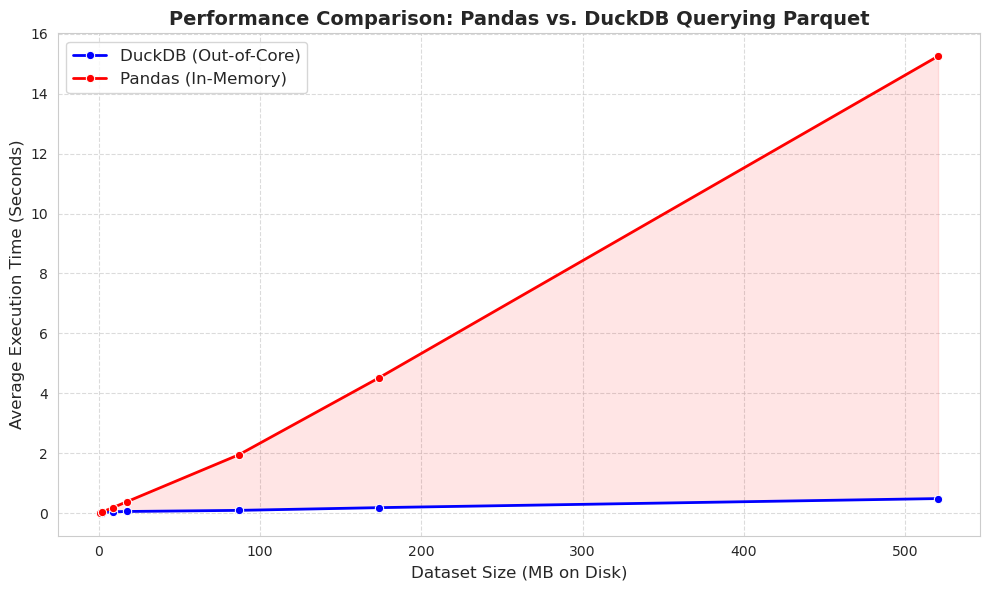

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_benchmark_results(df):
    """
    Generates a line plot comparing Pandas and DuckDB execution times 
    as the dataset size increases.
    """
    
    # Filter out the "OOM Error" rows so they don't break the plot
    # We only want to plot the iterations that successfully completed
    plot_df = df[df['Pandas_Avg_Sec'] != 'OOM Error'].copy()
    
    # Ensure columns are numeric
    plot_df['Size_MB'] = pd.to_numeric(plot_df['Size_MB'])
    plot_df['DuckDB_Avg_Sec'] = pd.to_numeric(plot_df['DuckDB_Avg_Sec'])
    plot_df['Pandas_Avg_Sec'] = pd.to_numeric(plot_df['Pandas_Avg_Sec'])

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Plot DuckDB performance
    sns.lineplot(
        data=plot_df, 
        x='Size_MB', 
        y='DuckDB_Avg_Sec', 
        marker='o', 
        linewidth=2, 
        label='DuckDB (Out-of-Core)', 
        color='blue'
    )

    # Plot Pandas performance
    sns.lineplot(
        data=plot_df, 
        x='Size_MB', 
        y='Pandas_Avg_Sec', 
        marker='o', 
        linewidth=2, 
        label='Pandas (In-Memory)', 
        color='red'
    )

    # Formatting and labels
    plt.title('Performance Comparison: Pandas vs. DuckDB Querying Parquet', fontsize=14, fontweight='bold')
    plt.xlabel('Dataset Size (MB on Disk)', fontsize=12)
    plt.ylabel('Average Execution Time (Seconds)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    
    # Add a subtle grid
    plt.grid(True, linestyle='--', alpha=0.7)

    # Optional: Fill the area between the curves to highlight the gap
    plt.fill_between(
        plot_df['Size_MB'], 
        plot_df['DuckDB_Avg_Sec'], 
        plot_df['Pandas_Avg_Sec'], 
        color='red', 
        alpha=0.1
    )

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_benchmark_results(final_scaling_results)

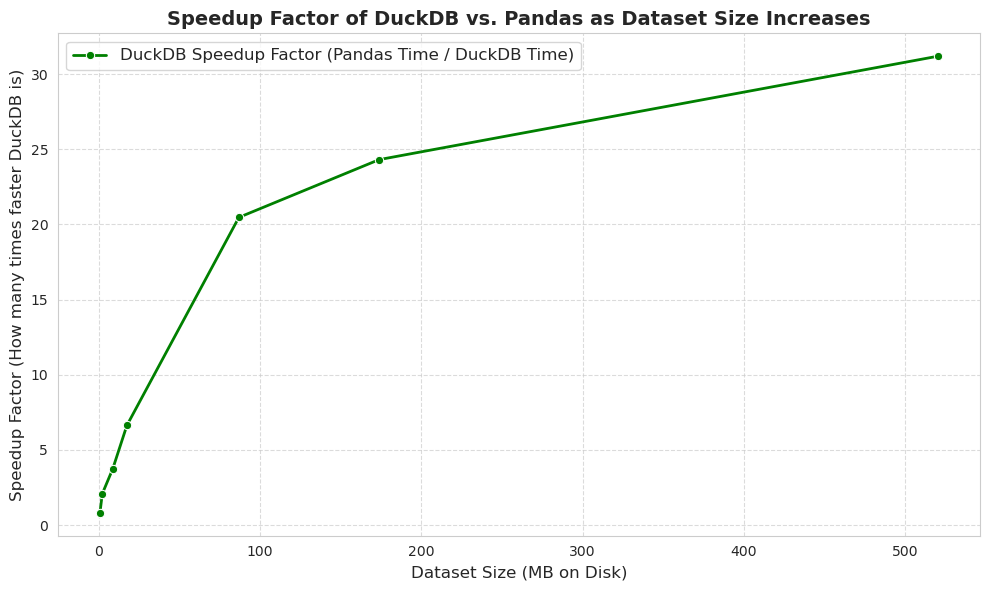

In [3]:
# Now lets plot the speedup factor as well to see how it changes with dataset size
def plot_speedup_factor(df):
    # Filter out the "OOM Error" rows so they don't break the plot
    plot_df = df[df['Pandas_Avg_Sec'] != 'OOM Error'].copy()
    
    # Ensure columns are numeric
    plot_df['Size_MB'] = pd.to_numeric(plot_df['Size_MB'])
    plot_df['DuckDB_Speedup_Factor'] = pd.to_numeric(plot_df['DuckDB_Speedup_Factor'], errors='coerce')

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    sns.lineplot(
        data=plot_df, 
        x='Size_MB', 
        y='DuckDB_Speedup_Factor', 
        marker='o', 
        linewidth=2, 
        label='DuckDB Speedup Factor (Pandas Time / DuckDB Time)', 
        color='green'
    )

    plt.title('Speedup Factor of DuckDB vs. Pandas as Dataset Size Increases', fontsize=14, fontweight='bold')
    plt.xlabel('Dataset Size (MB on Disk)', fontsize=12)
    plt.ylabel('Speedup Factor (How many times faster DuckDB is)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
plot_speedup_factor(final_scaling_results)

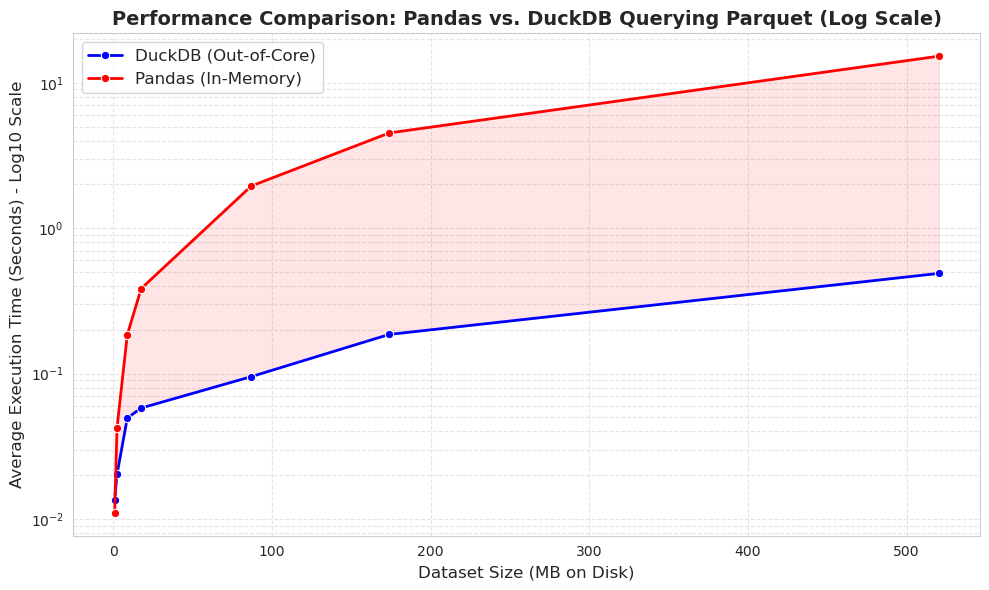

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_benchmark_results_log_scale(df):
    """
    Generates a line plot comparing Pandas and DuckDB execution times 
    as the dataset size increases, using a logarithmic y-axis.
    """
    
    # Filter out the "OOM Error" rows so they don't break the plot
    plot_df = df[df['Pandas_Avg_Sec'] != 'OOM Error'].copy()
    
    # Ensure columns are numeric
    plot_df['Size_MB'] = pd.to_numeric(plot_df['Size_MB'])
    plot_df['DuckDB_Avg_Sec'] = pd.to_numeric(plot_df['DuckDB_Avg_Sec'])
    plot_df['Pandas_Avg_Sec'] = pd.to_numeric(plot_df['Pandas_Avg_Sec'])

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # Plot DuckDB performance
    sns.lineplot(
        data=plot_df, 
        x='Size_MB', 
        y='DuckDB_Avg_Sec', 
        marker='o', 
        linewidth=2, 
        label='DuckDB (Out-of-Core)', 
        color='blue'
    )

    # Plot Pandas performance
    sns.lineplot(
        data=plot_df, 
        x='Size_MB', 
        y='Pandas_Avg_Sec', 
        marker='o', 
        linewidth=2, 
        label='Pandas (In-Memory)', 
        color='red'
    )

    # --- THE CRITICAL CHANGE ---
    plt.yscale('log')
    # ---------------------------

    # Formatting and labels
    plt.title('Performance Comparison: Pandas vs. DuckDB Querying Parquet (Log Scale)', fontsize=14, fontweight='bold')
    plt.xlabel('Dataset Size (MB on Disk)', fontsize=12)
    plt.ylabel('Average Execution Time (Seconds) - Log10 Scale', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    
    # Add a subtle grid that handles both major and minor log ticks
    plt.grid(True, which="both", linestyle='--', alpha=0.5)

    # Optional: Fill the area between the curves to highlight the gap
    plt.fill_between(
        plot_df['Size_MB'], 
        plot_df['DuckDB_Avg_Sec'], 
        plot_df['Pandas_Avg_Sec'], 
        color='red', 
        alpha=0.1
    )

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_benchmark_results_log_scale(final_scaling_results)

# Results

Wow, I wasn't expecting such a speedup that early. After [some reading](https://arrow.apache.org/blog/2022/12/26/querying-parquet-with-millisecond-latency/), we have our answers:

* Projection Pushdown: The sites dataset has 37 columns. When I call pd.read_parquet(path), Pandas loads all 37 columns into RAM before it does any counting. DuckDB's query engine looks at the SQL statement, realizes I only asked about MonitoringLocationName, and physically only reads that single column chunk from the disk, ignoring the other 36 columns completely.
* Pandas copies to ram: Pandas has to deserialize the Parquet data and translate it into Python/Numpy objects in memory. DuckDB operates directly on the vectorized Parquet data format. No copy, less I/O delay.